In [84]:
import numpy as np
import pickle
from torch.utils.data import DataLoader, TensorDataset,  random_split
from typing import Union
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch
import os
import tifffile as tif
import random
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from matplotlib.patches import Patch


In [ ]:
from general_utils import General, Metrics
from train import train
from unet.models import UNet, AttentionUNet
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Subset
from PIL import Image
from torchvision.transforms import v2

In [3]:
class TIFFSegmentationDataset(torch.utils.data.Dataset):
    
    def __init__(self, img_dir, mask_dir, patch_size=1024):

        self.img_dir = img_dir
        self.mask_dir = mask_dir
        # Patch size is not really used 
        self.patch_size = patch_size
        self.resize = v2.Resize((256, 256))

        all_files = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".tif", ".tiff"))
        ])

        # filtrar imágenes sin tumor
        self.files = []

        for f in all_files:
            mask_path = os.path.join(mask_dir, f)

            # si no existe la máscara → se descarta
            if not os.path.exists(mask_path):
                continue

            self.files.append(f)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        img_path = os.path.join(self.img_dir, name)
        mask_path = os.path.join(self.mask_dir, name)

        # Cargar y copiar para evitar problemas de memoria
        image = tif.imread(img_path).copy()
        mask = tif.imread(mask_path).copy()

        if image.ndim == 3: image = image[..., 0]
        if mask.ndim == 3: mask = mask[..., 0]

        # Convertir a Tensores [1, H, W]
        image_t = torch.from_numpy(image).unsqueeze(0).float() / 255.0
        mask_t = torch.from_numpy(mask).unsqueeze(0).float()
        mask_t = (mask_t > 0).float()

        # Scaling the pictures
        image_res = self.resize(image_t)
        mask_res = self.resize(mask_t)
        
        # Turn masks into binary files
        mask_res = (mask_res > 0.5).float()

        return image_res, mask_res

## **SOBRE LA CLASE DEL DATASET**

In [12]:
# Retrieve data 
dataset = TIFFSegmentationDataset(
    img_dir=r"./dataset/TIFF Images",
    mask_dir=r"./dataset/ROI Masks")

In [138]:
def overlapping_plot(img:torch.Tensor, name:str,  mask_gt:torch.Tensor, mask_pre:torch.Tensor)->None:
        """
            Function aimed to visualize img tensor and its 
            overlap with the masks

            Params:
                patch(torch.Tensor): The image 
                name(str): The name of the image
                mask_gt(torch.Tensor): The ground truth mask
                mask_pre(torch.Tensor): The predicted mask
        """

        # Show the main image 
        plt.figure(figsize = (8,8))
        plt.imshow(img, cmap = 'gray')

        # Define types of predictions
        tp = (mask_gt==1)&(mask_pre==1)
        fp = (mask_pre==1)&(mask_gt==0)
        fn = (mask_pre==0)&(mask_gt==1)

        # Print tp, fp, fn
        plt.imshow(np.ma.masked_where(~tp, tp), vmin = 0, vmax = 1, cmap = 'Greens', alpha = 0.6)
        plt.imshow(np.ma.masked_where(~fp, fp), vmin = 0, vmax = 1, cmap = 'Reds')
        plt.imshow(np.ma.masked_where(~fn, fn),vmin = 0, vmax = 1,  cmap = 'summer')
        # Enhance the plot
        plt.title('Overlap between gt and predicted mask', fontweight = 'bold')
        plt.axis('off')

        # Extract metrics
        overlap_degree = round(((mask_gt*mask_pre).sum()/(mask_gt.sum())).item(), 3)

        # Define handles for the legend
        legend_handles = [
            Patch(facecolor = 'green', label = f'True Positives'),
            Patch(facecolor = 'red', label = f'False Positives'),
            Patch(facecolor = 'yellow', label = f'False Negatives'),
            Patch(facecolor = 'None', label = f'Overlap degree({overlap_degree})')
        ]
        plt.legend(handles = legend_handles, loc='upper left')
        
        # Save the figure
        os.makedirs('./test_visz', exist_ok = True)
        plt.savefig(f'./test_visz/{name}.png')
        plt.close()

In [143]:
for index,(a, b) in enumerate(test_dataloader):
    for i in range(a.shape[0]):
        overlapping_plot(a[i,0,:,:], f'batch({index})-image{i}',b[i,0,:,:],b[i,0,:,:])

## **CARGA REAL**

In [160]:
# Define train and test split sizes
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset)- (train_size + val_size)
# Define the splits and store them only once
path_data = './data'
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
General.serialize_data(train_dataset, path_data,  name = 'train.pkl')
General.serialize_data(val_dataset, path_data,  name = 'val.pkl')
General.serialize_data(test_dataset, path_data, name = 'test.pkl')

The dir (./data) exists
The dir (./data) exists
The dir (./data) exists


## **DEPURACIÓN CON OXFORD**

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms.functional as TF
import random

# --- Transformaciones sincronizadas ---
class JointTransform:
    def __init__(self, size=(256, 256)):
        self.size = size

    def __call__(self, img, mask):
        # Resize
        img = TF.resize(img, self.size)
        mask = TF.resize(mask, self.size, interpolation=TF.InterpolationMode.NEAREST)

        # Random horizontal flip (sincronizado)
        if random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # A tensor
        img = TF.to_tensor(img)

        # Mascara: convertir a tensor SIN normalizar
        mask = torch.as_tensor(TF.pil_to_tensor(mask), dtype=torch.long)

        # Oxford Pets: clases {1,2,3} → fondo/objeto/borde
        # Para binario: objeto = 1, resto = 0
        mask = (mask == 1).long()

        return img, mask


# --- Dataset wrapper ---
class OxfordPetSegmentation(torch.utils.data.Dataset):
    def __init__(self, root, split="trainval", transform=None):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]

        if self.transform:
            img, mask = self.transform(img, mask)

        return img, mask


# --- Crear dataset y dataloader ---
transform = JointTransform(size=(256, 256))

train_dataset = OxfordPetSegmentation(
    root="./data",
    split="trainval",
    transform=transform
)


100%|██████████| 792M/792M [07:18<00:00, 1.81MB/s]  
100%|██████████| 19.2M/19.2M [00:10<00:00, 1.87MB/s]


In [10]:
torch.manual_seed(0)

# --- Dataset completo ---
full_train_dataset = OxfordPetSegmentation(root="./data", split="trainval", transform=transform)
test_dataset       = OxfordPetSegmentation(root="./data", split="test",     transform=transform)

# --- Splits train/val ---
n_total = len(full_train_dataset)  # ~3680
n_val   = int(n_total * 0.15)      # ~552
n_train = n_total - n_val          # ~3128

indices     = torch.randperm(n_total)
train_subset = Subset(full_train_dataset, indices[:n_train])
val_subset   = Subset(full_train_dataset, indices[n_train:])

# --- Dataloaders ---
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_dataloader   = DataLoader(val_subset,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_dataloader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}')

Train: 3128 | Val: 552 | Test: 3669


## **TRAIN**

In [6]:
def dice(pred, target, smooth = 1e-16)->float:
    """ 
        Function aimed to compute the dice
        loss (1- (2|A∩B|)/(|A| + |B|))

        Domain:
            1: Perfect matching
            0: No matching

        Params:
            pred(torch.Tensor): The predicted tensor
            target(torch.Tensor): The ground truth labels
            smooth(float): The value to avoid numerical issues
        Returns:
            result(float): The dice loss
    
    """

    pred = torch.sigmoid(pred)
    pred = pred.view(pred.shape[0], pred.shape[1], -1)
    target = target.view(target.shape[0], target.shape[1], -1)
    #print(pred.shape, target.shape)

    intersection = (pred*target).sum(dim = 2)
    union = pred.sum(dim=2) + target.sum(dim=2)
    dice = (2*intersection + smooth)/(union+smooth)

    return (1-dice).mean()

In [7]:
def combined_loss(output:torch.Tensor, labels:torch.Tensor, bce_criterion, alpha:float)->float:
    """
        Function aimed to provide a weighted combined loss schedule.It 
        includes BCE and DICE. The weight they're provided depends on 
        which phase of the process we are currently at; preferring
        greater important of BCE for earlier stages. 
    
        
        Params:
            output(torch.Tensor): Net's output
            labels(torch.Tensor): Label's tensor
            bce_criterion(BCEWithLogitsLoss): The bce loss criterion
            alpha(float): The weighting value

        Returns:
            final_loss(float): The final loss value

   """
    # Compute bce
    bce = bce_criterion(output, labels)
    
    # Compute dice
    probs = torch.sigmoid(output)
    smooth =  1e-6
    intersection = (probs * labels).sum(dim=(1,2,3))
    dice_loss = 1 - (2. * intersection + smooth) / (
        probs.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3)) + smooth)
    return alpha * bce + (1-alpha) * dice_loss.mean()

In [8]:
def plotting_module(loss_values:dict[str, tuple[float]],title:str, name:str)->None:
    """     
        Function aimed to visualize train and validation
        loss per epoch. 

        Params:
            loss_values(dict[str, tuple[float]]): The loss values
            title(str): The main title for the plot
            name(str): The name of the figure
        Returns:
            None
    """

    # Define the figure
    fig, axes = plt.subplots(1,2, figsize = (10,5))

    # Get the values
    train_loss, val_loss = list(zip(*loss_values.values()))
    
    # Set main tile
    plt.suptitle(title, fontweight = 'bold')
    # Define the first plot
    axes[0].set_title('Train loss evolution', fontweight = 'bold')
    axes[0].plot(train_loss)
    axes[0].set_xlabel('Epoch', color = 'red')
    axes[0].set_ylabel("Cumulative loss", color = 'red')

    # Define the second plot
    axes[1].set_title('Validation loss evolution', fontweight = 'bold')
    axes[1].plot(val_loss)
    # Save the image 
    base_path = './loss'
    os.makedirs(base_path, exist_ok = True)
    plt.savefig(f'{base_path}/{name}.png', dpi = 600)

    
    plt.show()

In [9]:
def train(modelname:str, val_loader, model:Union[UNet, AttentionUNet], dataloader:DataLoader, epochs:int, device:str, path:str, weight:float, plot:bool)->list[float]:
    """ 
        Function aimed to train the given model 
        over a given dataset

        Params:
            modelname(str): The name of the model
            model(Union[UNet, AttentionUnet]): The selected model
            dataloader(DataLoader): The object to sample batches from
            epochs(int): The number of epochs
            device(str): Define the device to use
            path(str): Model's storing path
            weight(float): The positive class weight
            plot(bool): If a plot is seeked or not

        Returns:
            loss(list[float]): The loss evolution (train, val)
    """

    # Define base loss and schedule
    weigth_tensor = torch.tensor(weight).to(device)
    base_criterion = nn.BCEWithLogitsLoss(pos_weight = weigth_tensor)

    
    # Define mode and device
    model.to(device)
    model.train()

    # Define scaler, scheduler and optimizer
    scaler = torch.amp.GradScaler(device)
    optimizer = optim.Adam(model.parameters(), lr  = 1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max = epochs*2, eta_min=1e-05)


    # Define reporting structures
    loss_storage = {}
    best_val = float('inf')

    # Iterate over the different epochs
    for epoch in range(epochs):
        epoch_loss = 0
        batch_loss = 0
        # Information print about the epoch
        print(f'\nEPOCH({epoch})')

        # Run each batch
        for i, batch in enumerate(dataloader):
            # Divide between input and data
            data, labels = batch
            # Matching the device
            data = data.to(device)
            labels = labels.to(device).float()
            
            # Set gradients to zero per batch
            optimizer.zero_grad()

            # Switching to automatic mixed precission
            with torch.amp.autocast(device):
                # Make predictions for the batch
                output = model(data)
                # Compute loss
                loss = combined_loss(output, labels, base_criterion,  0.5)

            # Scales loss. Calls backward() on scaled loss to create scaled gradients.
            scaler.scale(loss).backward()

            # Perform an optimizer's step
            scaler.step(optimizer)
            scaler.update()

            # Update data and report
            batch_loss +=loss.item()
            epoch_loss +=loss.item()

            # XBatch information
            if (i+1)%10 == 0:
                avg_loss = batch_loss/10
                print(f"·Batch({i+1}):loss({avg_loss})")
                batch_loss = 0

        # Perform scheduler step -> case Cossine LR scheduler
        scheduler.step()

        # Validation -> the end of each epoch
        # Set the model to eval
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                # Load data and labels
                data, labels = batch
                # Set the device
                data, labels = data.to(device), labels.to(device).float()
                # Apply automatic quantization
                with torch.amp.autocast(device_type = device):
                    # Get output and loss
                    output = model(data)
                    val_loss += combined_loss(output, labels, base_criterion, alpha = 0.5).item()

        # Handle validation loss
        avg_val_loss = val_loss / len(val_loader)
        # Scheduler step based on validation
        #scheduler.step(avg_val_loss)
        #print("LR:", optimizer.param_groups[0]['lr'])
        # Model storage based on validation loss
        if avg_val_loss < best_val:
            best_val = avg_val_loss
            torch.save(model.state_dict(), f'{path}/{modelname}.pth')
        
        # Handle train loss behaviour
        avg_loss = epoch_loss/len(dataloader)
        loss_storage[epoch] = (avg_loss, avg_val_loss)
       
    
        # Info printing about loss
        print(f'Val loss: {avg_val_loss:.4f}')
        print(f'Cumulated loss epoch:{avg_loss}')

        # Set model again to train
        model.train() 

    
    # Save the trained model -> now is validation-based approach
    #torch.save(model.state_dict(), f'{path}/{modelname}.pth')  

    # Save train-val loss curves
    try:
        if plot:
            title = f"Epochs({epochs})|No loss schedule|"
            plotting_module(loss_storage, title, modelname)
    except:
        pass

    return loss_storage

In [10]:
# Retrieve train object
path_data = './data'
train_dataset = General.recover_data(path_data, name = 'train')

# Generate a DataLoader object for train
train_dataloader = DataLoader(
    train_dataset,
    batch_size=3,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
# Retrieve val object
val_dataset = General.recover_data(path_data, name = 'val')

# Generate a DataLoader object for train
val_dataloader = DataLoader(
    train_dataset,
    batch_size=3,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [ ]:
# Get the weights 
all_data = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=1,
    pin_memory=True
)
weight = General.metametrics(all_data)

The dir (./models) exists

EPOCH(0)
·Batch(10):loss(0.8364228665828705)
·Batch(20):loss(0.7722430288791656)
·Batch(30):loss(0.7406180322170257)
·Batch(40):loss(0.7417874217033387)
·Batch(50):loss(0.7242352366447449)
·Batch(60):loss(0.706824004650116)
Val loss: 0.7172
Cumulated loss epoch:0.7514979508188036

EPOCH(1)
·Batch(10):loss(0.6849165201187134)
·Batch(20):loss(0.6821917355060577)
·Batch(30):loss(0.7147049129009246)
·Batch(40):loss(0.683022266626358)
·Batch(50):loss(0.6585760533809661)
·Batch(60):loss(0.6622528553009033)
Val loss: 0.7682
Cumulated loss epoch:0.6805243946257091

EPOCH(2)
·Batch(10):loss(0.6639806985855102)
·Batch(20):loss(0.6849567294120789)
·Batch(30):loss(0.6522789239883423)
·Batch(40):loss(0.6437702298164367)
·Batch(50):loss(0.6544937133789063)
·Batch(60):loss(0.6414694130420685)
Val loss: 0.6349
Cumulated loss epoch:0.6562554864656358

EPOCH(3)
·Batch(10):loss(0.665703409910202)
·Batch(20):loss(0.6301774919033051)
·Batch(30):loss(0.6252984881401062)
·Batch(40)

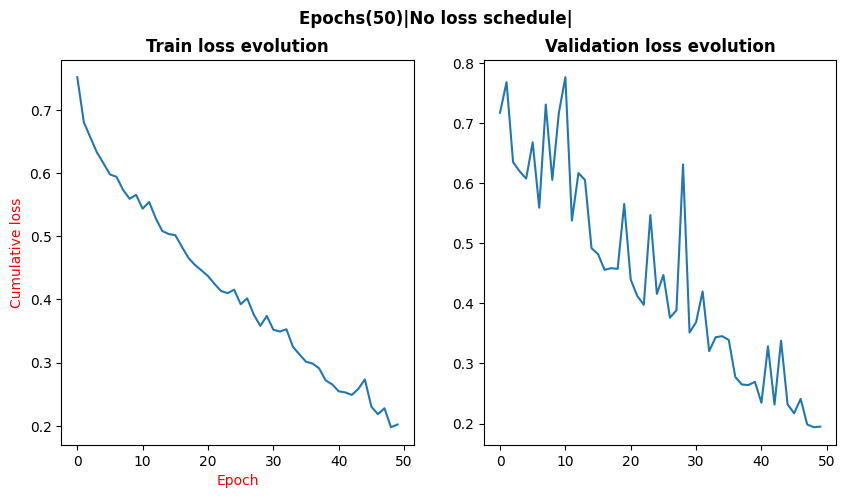

In [11]:
# Check model's storing path
path_model = './models'
General.ensure_dir(path_model)

# Compute metametrics for weighting
weight = 9

# Create model and params
model = AttentionUNet(in_channels = 1, num_classes = 1) 
epochs = 50
device = 'cuda'if torch.cuda.is_available() else "cpu"

# Call training with the model
modelname = '50_epoch_cosine_lr_3e005_best_val_model'
plot = True
loss_values = train(modelname, val_dataloader, model, train_dataloader, epochs, device, path_model, weight, plot)

## **TEST**

In [ ]:
probada: 
    1. cosine, lr 1e-4 loss 0.5
    2. plateua lr 1e-4 loss 0.5

In [168]:
def test(modelname:str, model:Union[UNet, AttentionUNet], dataloader:DataLoader, device:str, path:str, sample:bool)->tuple[dict, torch.Tensor]:
    """ 
        Function aimed to provide testing over a given model
        given model 

        Params:
            modelname(str): The name of the model to load
            model(Union[UNet, AttentionUnet]): The given model 
            dataloader(DataLoader): The given dataset
            device(str): Define the device to use
            path(str): The path to load the model from
            sample(bool): If showing an image is seeeked


        Returns:
            A tuple of:
                - metrics(dict[str, float]): The dictionary of metrics
                - embedding_tensor(torch.Tensor): The tensor containing the embeddings
    """


    # Load the model  -> build path adding name
    model_path  = path + f'/{modelname}.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)

    # Define random image plot
    batch_idx = [random.randint(0, len(dataloader)-1) for i in range(3)] if sample else [i for i in range(len(dataloader))]
    batch_idx = list(set(batch_idx))
    print('The random batches to overlap:', batch_idx if sample is True else 'all')

    # Set the model to evaluation
    model.eval()

    # Define the storage structures
    prediction_list = []
    labels_list = []
    embedding_list = []
    # Generate the outputs
    with torch.no_grad():
        for idx, (data, labels) in enumerate(dataloader):

            data = data.to(device)
            # Get the output from the model 
            logits = model(data)
            # Get the prediction [0,1]-->sigmoid(logit)
            probability = torch.sigmoid(logits)
            classification = (probability>0.5).float()

            # Store the pair (output, labels)
            prediction_list.append(classification.cpu())
            labels_list.append(labels.cpu())

            # Store the embedding
            embedding_list.append(model.embedding_storage.detach().cpu())

            # Generate random image from selected batch
            if idx in batch_idx:
                # Select random img from the batch
                random_image = random.randint(0, data.shape[0]-1)
                # Call the overlapping plot
                overlapping_plot(
                    data[random_image, 0].cpu(),
                    f"test_batch_{idx}_image_{random_image}",
                    labels[random_image, 0].cpu(),
                    classification[random_image, 0].cpu(),
                )


    # Create structure to feed the metrics class (total, ch, h, w)
    predictions_tensor = torch.cat(prediction_list)
    labels_tensor  = torch.cat(labels_list)
    embeddings_tensor = torch.cat(embedding_list)

    # Metrics management
    metrics = Metrics(predictions_tensor, labels_tensor)

    # Create the metrics
    metrics.feed_metrics()

    # Show info
    print(metrics)

    return metrics.metrics, embeddings_tensor

In [162]:
# Retrieve train data
path_data = './data'
test_dataset = General.recover_data(path_data, name = 'test')

# Generate a DataLoader object for train
test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [169]:
# Define the model to load
path_model = './models'
model = AttentionUNet(in_channels = 1, num_classes = 1) 
device = 'cuda' if torch.cuda.is_available() else "cpu"
name = '50_epoch_cosine_lr_3e005_best_val_model'

# Call testing
metrics, embedding = test(name, model, test_dataloader, device, path_model, sample = False)

***************
METRICS SUMMARY
***************
·Dice: 0.6134

